In [8]:
import numpy as np
import matplotlib.pyplot as plt
import healpy as hp

%matplotlib inline

In [2]:
file_dir = '/seagate/home/experiments/20231217/cly/bristow/'

(16, 16, 3)


/home/remington/borealis_postprocessors/venv/lib64/python3.9/site-packages/healpy/projector.py:201: ComplexWarning: Casting complex values to real discards the imaginary part
  img[w] = mpix


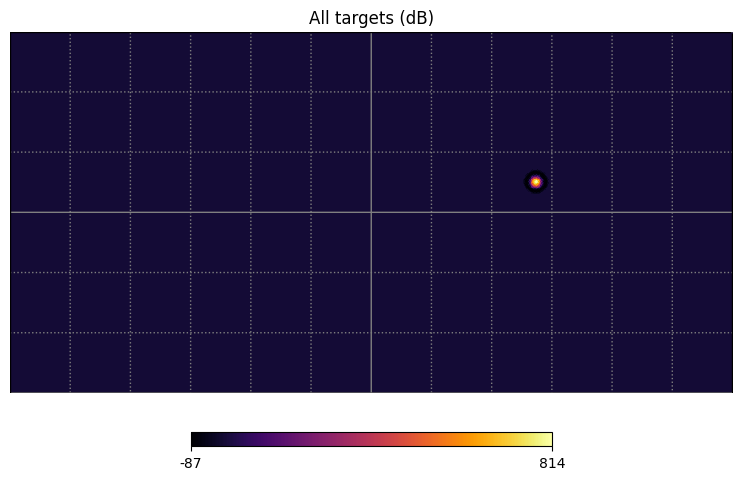

In [273]:
from collections import OrderedDict

freq = 10.8e6
wavelength = 299792458 / freq

nside = 128
lmax = 65
npix = hp.nside2npix(nside)
theta, phi = hp.pix2ang(nside=nside, ipix=np.arange(npix // 2))     # in radians
fov = np.stack([phi, theta], axis=1)

# [x, y, z] offsets for each antenna
antenna_locations = np.zeros((16, 3), dtype=np.float32)
antenna_locations[:16, 0] = np.arange(16) * 15.24  # main array, leftmost is at [0, 0]
# antenna_locations[16:, 0] = np.arange(6, 10) * 15.24  # intf array
# antenna_locations[16:, 1] = -100.0  # intf array 100m behind main array

# [num_antennas, num_antennas]
baselines = antenna_locations[:, np.newaxis] - antenna_locations[np.newaxis, :]
print(baselines.shape)

# array of targets, represented as (magnitude, colatitude, phi, spread) tuples.
spread_targets = np.array([
    [3, 75, 82, 2],
    # [2, 75, 90, 3],
    # [0.7, 85, 80, 2],
], dtype=np.float32)

# array of targets, represented as (magnitude, colatitude, phi) tuples.
point_targets = np.array([
    # [90, 89, 88],
], dtype=np.float32)

phase_measurements = np.zeros((antenna_locations.shape[0],), dtype=np.complex64)

background_noise_power = -10
full_target_sky = np.zeros((fov.shape[0] * 2,), dtype=np.complex64)
# random_power = np.random.standard_normal(fov.shape[0] * 2) + background_noise_power

# count, bins, ignored = plt.hist(random_power, 30, density=True)
# plt.plot(bins, 1/(1 * np.sqrt(2 * np.pi)) *
#                np.exp( - (bins - 0)**2 / (2 * 1**2) ),
#          linewidth=2, color='r')
# plt.show()

# random_phase = np.random.uniform(0, 1, fov.shape[0] * 2) * 2 * np.pi


target_sky = np.zeros((len(fov),), dtype=np.complex64)
# target_sky = np.power(10, random_power[:fov.shape[0]] / 20) * np.exp(1j * random_phase[:fov.shape[0]])
# full_target_sky = np.power(10, random_power / 20) * np.exp(1j * random_phase)

# Add the spread targets to the sky
for i in range(spread_targets.shape[0]):
    target_colatitude = np.deg2rad(spread_targets[i, 1])
    target_phi = np.deg2rad(spread_targets[i, 2])
    target_width = np.deg2rad(spread_targets[i, 3])
    
    # Create a Gaussian beam for the target in sky space
    blm = hp.blm_gauss(target_width, lmax=lmax, pol=False)[0]
    rot = hp.Rotator(rot=(np.pi+target_phi, target_colatitude, 0), deg=False, inv=True)
    target_map = rot.rotate_map_alms(hp.alm2map(blm, nside=nside, lmax=lmax, mmax=0, pol=False))

    # Truncate beam to avoid ringing
    vec = hp.ang2vec(target_colatitude, target_phi)
    relevant_pixels = hp.query_disc(nside=nside, vec=vec, radius=3 * target_width)
    target_sky[relevant_pixels] = spread_targets[i, 0] * target_map[relevant_pixels]

    # Add target to sky
    full_target_sky[:len(fov)] += target_sky

# Add the contributions of spread targets
if spread_targets.shape[0] > 0:    
    wave_vectors = -1 * np.stack([np.sin(fov[:, 1]) * np.cos(fov[:, 0]), 
                                  np.sin(fov[:, 1]) * np.sin(fov[:, 0]), 
                                  np.cos(fov[:, 1])
                                 ], axis=1)
    wave_components = np.einsum('ak,ik->ai', antenna_locations, wave_vectors, optimize='greedy')
    phase_measurements += np.einsum('i,ai->a', target_sky, np.exp(1j * wave_components * 2 * np.pi / wavelength), optimize='greedy')

# Add the contribution of point targets
for i in range(point_targets.shape[0]):
    target_colatitude = np.deg2rad(point_targets[i, 1])
    target_phi = np.deg2rad(point_targets[i, 2])
    wave_vector = -1 * np.array([np.sin(target_colatitude) * np.cos(target_phi), 
                                 np.sin(target_colatitude) * np.sin(target_phi), 
                                 np.cos(target_colatitude)])
    wave_components = np.einsum('ak,k->a', antenna_locations, wave_vector, optimize='greedy')
    phase_measurements += point_targets[i, 0] * np.exp(1j * wave_components * 2 * np.pi / wavelength)
if point_targets.shape[0] > 0:
    full_target_sky[hp.ang2pix(nside, 
                               np.deg2rad(point_targets[:, 1]), 
                               np.deg2rad(point_targets[:, 2])
                              )] += point_targets[:, 0]

# visibilities = phase_measurements[:, np.newaxis] * phase_measurements[np.newaxis, :].conj()
# unique_visibilities = np.zeros((len(unique_baselines.keys())), dtype=np.complex64)

# Plot the targets in the sky
hp.cartview(full_target_sky, title=f'All targets (dB)',
            # rot=(90, 0, 0), 
            # half_sky=True,
            flip='geo', cmap='inferno')
hp.graticule(color='grey')

-38.225456


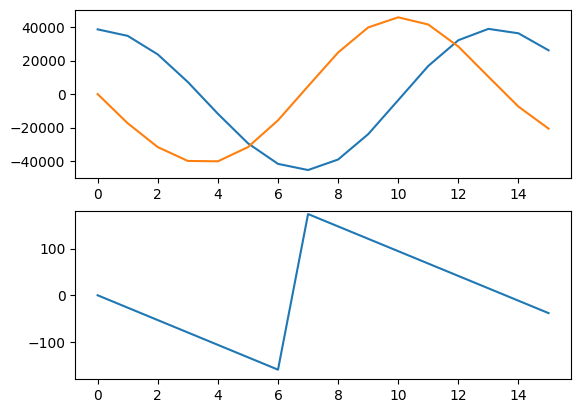

In [274]:
fig, ax = plt.subplots(2, 1)
ax[0].plot(phase_measurements.real)
ax[0].plot(phase_measurements.imag)
ax[1].plot(np.rad2deg(np.angle(phase_measurements)))
ax[1].set_ylim(-180, 180)
print(np.rad2deg(np.angle(phase_measurements[-1])))

# Bristow Imaging

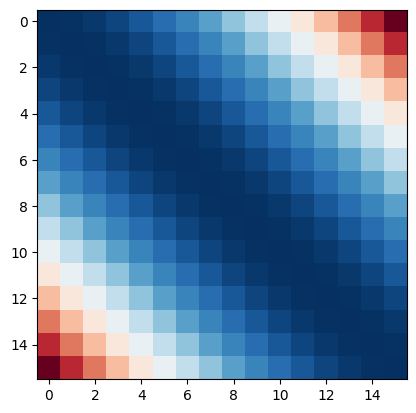

(256, 91)


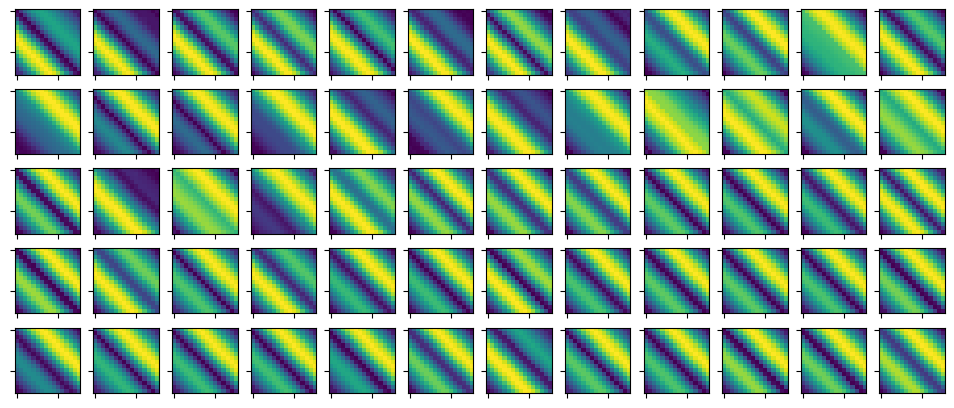

In [281]:
directions_deg = np.arange(-45, 45.5)
directions_rad = np.deg2rad(directions_deg)

wave_num = 2.0 * np.pi / wavelength
exponents = np.einsum('ab,c->abc', wave_num * baselines[:, :, 0], np.sin(directions_rad))
B = np.exp(-1j * exponents, dtype=np.complex64)

angle_bin = 44

fig, ax = plt.subplots(1, 1)
ax.imshow(B[..., angle_bin].real, cmap="RdBu")
plt.show()
B = B.reshape((B.shape[0] ** 2, -1))
print(B.shape)

# B_inv = np.linalg.pinv(B)
B_inv = np.matmul(
    np.linalg.inv(
        np.matmul(
            B.T.conj(), 
            B
        )
    ), 
    B.T.conj(),
)

fig, ax = plt.subplots(5, 12, figsize=(12, 5), sharex='all', sharey='all')
ax = ax.flatten()
for i in range(60):
    ax[i].imshow(np.abs(B_inv[i, :].reshape((16, 16))))
    ax[i].set_xticklabels([])
    ax[i].set_yticklabels([])
    ax[i].set_aspect('equal')
plt.subplots_adjust(wspace=None, hspace=None)
plt.show()
# ax[0].imshow(B_inv[angle_bin, :].reshape((16, 16)).real, cmap="RdBu")
# ax[1].imshow(B_inv[angle_bin, :].reshape((16, 16)).imag, cmap="RdBu")
# ax[2].imshow(np.abs(B_inv[angle_bin, :]).reshape((16, 16)))
# plt.show()

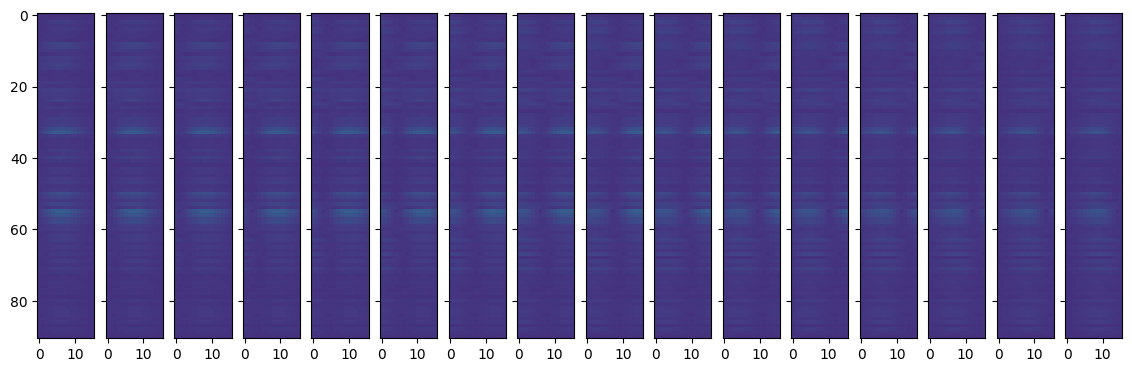

In [283]:
corr_idx = 15

fig, ax = plt.subplots(1, 16, figsize=(14, 6), sharey='all')
for i in range(16):
    im = ax[i].imshow(np.abs(B_inv.reshape((-1, 16, 16))[:, i, :]), vmin=-10, vmax=60)
plt.show()

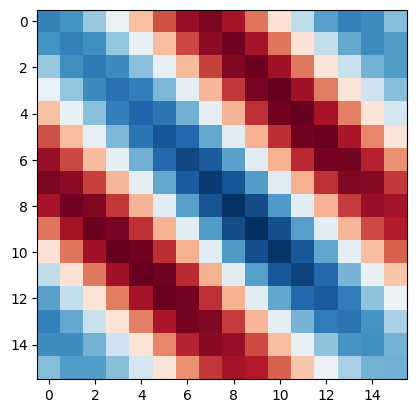

(256,)
(91,)


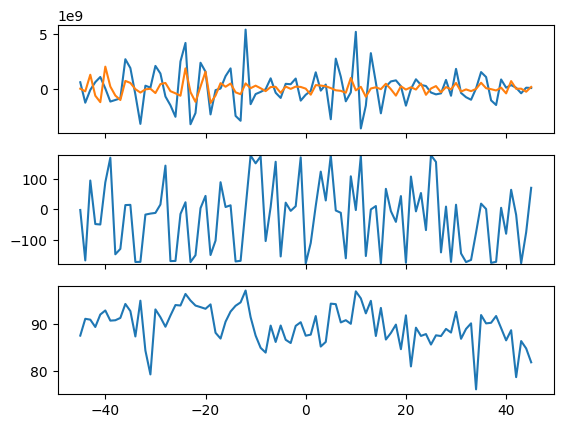

In [284]:
# Calculate the correlations from the data
correlations = phase_measurements[:, np.newaxis] * phase_measurements[np.newaxis, :].conj()

fig, ax = plt.subplots(1, 1)
ax.imshow(correlations.real, cmap="RdBu")
plt.show()

correlations = correlations.reshape((phase_measurements.shape[0] ** 2,))
print(correlations.shape)

# Find the least-squares solution for the angular spectrum
result = np.matmul(B_inv, correlations)
print(result.shape)

fig, ax = plt.subplots(3, 1, sharex='all')
ax[0].plot(directions_deg, result.real)
ax[0].plot(directions_deg, result.imag)
ax[1].plot(directions_deg, np.rad2deg(np.angle(result)))
ax[1].set_ylim(-180, 180)
ax[2].plot(directions_deg, 10 * np.log10(np.abs(result)))
plt.show()